In [1]:
from utils.data_loader import load_breast_cancer_data, load_folktables_income_data, load_loan_prediction, \
    load_gbs_gesis, load_gbs_allensbach, load_folktables_employment_data
from utils.metrics import compute_test_metrics_fw_mrs, train_feature_weighted_random_forest, train_feature_weighted_decision_tree
from utils.gradient_descent import compute_classification_metrics_gradient_descent
import seaborn as sns
import numpy as np
np.random.seed(5)
from utils.sampling import sample, sample_with_test_set
from sklearn.preprocessing import StandardScaler
from weighting_methods.feature_weighted_maximum_representative_subsampling import mrs_without_cv, mrs, \
    compute_feature_weights_with_budget, compute_feature_weights_with_temperature
from utils.metrics import compute_classification_metrics_random_forest, \
    compute_classification_metrics_tree, compute_classification_metrics_feature_weights

2024-05-23 14:53:59.096001: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [ ]:
def compute_feature_weights_temperature(budget, feature_importance):
    if budget is None:
        return np.ones(len(feature_importance)) / len(feature_importance)
    else:
        weights =  np.exp(-feature_importance / budget)
    return weights / np.sum(weights)

def compute_feature_weights_with_budget(budget, feature_importance):
    if budget is None:
        return np.ones(len(feature_importance))
    else:
        max_importance = np.max(feature_importance)
        min_importance = np.min(feature_importance)
        feature_importance = (feature_importance - min_importance)  / (max_importance - min_importance)
        scaled_feature_importance = feature_importance * budget
        scaled_feature_importance = 1 + scaled_feature_importance
        return scaled_feature_importance 

In [ ]:
df, columns, target = load_breast_cancer_data()
df[columns] = StandardScaler().fit_transform(df[columns])
# N = df[df["label"] == 1]
# R = df[df["label"] == 0]
N, R, T = sample_with_test_set(
           "less_positive_class",
           df,
           target,
           train_fraction=0.5,
           bias_fraction=0.1,
           test_fraction=0.2,
           columns=columns,
       )
dropped_N = N.copy().reset_index(drop=True)

In [ ]:
# _, feature_importance = mrs_without_cv(dropped_N, R, columns, class_weights="balanced", random_state=5, drop=20)
drop_ids, feature_importance_cv = mrs(dropped_N, R, columns, class_weights="balanced", random_state=5, drop=50)

<Axes: >

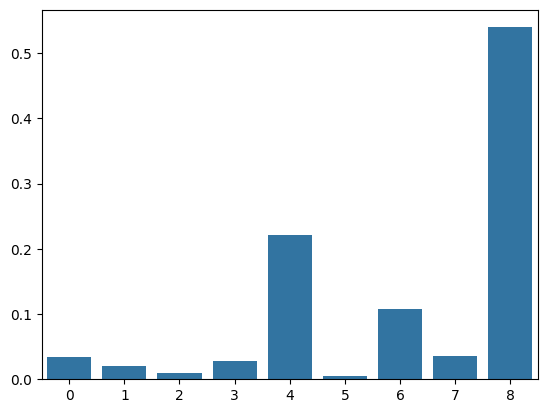

In [ ]:
feature_weights = compute_feature_weights_with_temperature(0.01, feature_importance_cv)
sns.barplot(feature_weights)

In [ ]:
seed = 5
max_features = "sqrt"
auroc_method = train_feature_weighted_random_forest
sample_weights = np.ones(len(N)) / len(N)
n_estimators=1000

feature_weights_list = []
budgets = [None, 0.1, 0.01, 0.005, 0.001]
for budget in budgets:
    feature_weights = compute_feature_weights_with_temperature(budget, feature_importance_cv)
    feature_weights_list.append(feature_weights)

In [ ]:
#for i, budget in enumerate(budgets):
#   auroc = compute_test_metrics_fw_mrs(
#       dropped_N,
#       R,
#       columns,
#       random_state=seed,
#       feature_weights=feature_weights_list[i],
#       method=auroc_method,
#       class_weight="balanced",
#       max_features="sqrt",
#       splitter="feature_weighted_best",
#       n_splits_test=5,
#       n_estimators=100,
#       draw_with_feature_weights=True,
#   )
#   print(f"{budget}: {auroc}")

None: 0.6039460683178859\
0.02: 0.5912344888376883\
0.05: 0.5493763819797175\
0.1: 0.5242090747237785

In [ ]:
for i,budget in enumerate(budgets):
        feature_weights = feature_weights_list[i]
        if i > 0:
                use_sample_weights[drop_ids] = 0
        else:
                use_sample_weights = sample_weights
        auroc, auprc = compute_classification_metrics_gradient_descent(
                N,
                R,
                R,
                columns,
                use_sample_weights,
                feature_weights,
                target,
                random_state=seed,
                regularization_name=None,
                n_splits=5,
        )
        print(f"{budget} Auroc: {auroc}")
        print(f"{budget} AUPRC: {auprc}\n")

ValueError: Found input variables with inconsistent numbers of samples: [37, 37, 144]

In [ ]:
def minimax_concave_penalty(weights, lambda_value=2, a=3):
        gradients = np.zeros(len(weights))
        indices = np.abs(weights) <= lambda_value * a
        gradients[indices] = np.sign(weights[indices]) * (
            lambda_value - (np.abs(weights[indices]) / a)
        )
        return gradients

In [ ]:
def smoothly_clipped_absolute_deviation(weights, lambda_value=2, a=3.7):
        gradients = np.zeros(len(weights))
        first_indices = np.abs(weights) <= lambda_value
        gradients[first_indices] = lambda_value * np.sign(weights[first_indices])

        second_indices = (lambda_value < np.abs(weights)) & (
            np.abs(weights) <= a * lambda_value
        )
        gradients[second_indices] = (
            (a * lambda_value - np.abs(weights[second_indices]))
            * np.sign(weights[second_indices])
        ) / (a - 1)

        return gradients

In [ ]:
x = np.linspace(-10, 10, 100)
y = smoothly_clipped_absolute_deviation(x)
sns.scatterplot(x=x, y=y)

In [ ]:
#for i,budget in enumerate(budgets):
#    feature_weights = feature_weights_list[i]
#    auroc, auprc = compute_classification_metrics_random_forest(
#            N,
#            R,
#            columns,
#            sample_weights,
#            feature_weights,
#            target,
#            random_state=seed,
#            n_splits=10,
#            splitter="feature_weighted_best",
#            n_estimators=200,
#            draw_with_feature_weights=False,
#    )
#    print(f"{budget} Auroc: {auroc}")
#    print(f"{budget} AUPRC: {auprc}\n")

In [ ]:
for i,budget in enumerate(budgets):
    auroc, auprc = compute_classification_metrics_tree(
            N,
            R,
            columns,
            sample_weights,
            feature_weights_list[i],
            target,
            random_state=seed,
            draw_with_feature_weights=True,
            n_splits=10,
            splitter="feature_weighted_best",
            max_features="sqrt",
    )
    print(f"{budget} Auroc: {auroc}")
    print(f"{budget} AUPRC: {auprc}\n")

In [ ]:
# dropped_N = dropped_N.drop(drop_ids)